# 04 — Portfolio and Risk Demo

This notebook demonstrates how exported signals map to portfolio-level benchmark metrics.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = ROOT / 'data' / 'processed'

pf_path = PROCESSED / 'portfolio_backtest_summary.csv'
snapshot_path = PROCESSED / 'signals_latest_snapshot.csv'
ml_pf_path = PROCESSED / 'ml_backtest_summary.csv'

missing = [p for p in [pf_path, snapshot_path, ml_pf_path] if not p.exists()]
print(f'Missing artifacts: {len(missing)}')
for p in missing:
    print(' -', p)

Missing artifacts: 0


In [5]:
pf = pd.read_csv(pf_path) if pf_path.exists() else pd.DataFrame()
snapshot = pd.read_csv(snapshot_path) if snapshot_path.exists() else pd.DataFrame()
ml_pf = pd.read_csv(ml_pf_path) if ml_pf_path.exists() else pd.DataFrame()

display(Markdown('## Portfolio Backtest Summary (Classical)'))
display(pf)

display(Markdown('## Portfolio Backtest Summary (ML)'))
display(ml_pf)

display(Markdown('## Latest Signal Snapshot Used by Strategy Layer'))
display(snapshot)

## Portfolio Backtest Summary (Classical)

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return
0,strategy,-0.2907,-0.0521,0.0053,-0.000262
1,naive_50_50,-0.2907,-0.0521,0.0053,-0.000262
2,disconnected_60_40,-0.3354,-0.0633,0.0063,-0.000358


## Portfolio Backtest Summary (ML)

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return,hit_ratio,active_pct
0,ml_strategy,1.9348,-0.0024,0.0018,0.002083,0.5278,0.6389
1,ml_passive_spread,-0.8269,-0.0700,0.0112,-0.001422,0.3333,1.0000


## Latest Signal Snapshot Used by Strategy Layer

,timestamp,signal_type,maturity_bucket,direction,strength,confidence
0,2026-05-21T04:35:09Z,spread,3M,0,1.4400,0.4800
1,2026-05-21T04:35:09Z,cip,3M,0,0.9400,0.3133
2,2026-05-21T04:35:09Z,spread,6M,0,1.3500,0.4500
3,2026-05-21T04:35:09Z,cip,6M,0,0.9900,0.3300
4,2026-05-21T04:35:09Z,spread,1Y,0,1.1400,0.3800
5,2026-05-21T04:35:09Z,cip,1Y,0,1.0600,0.3533
6,2026-05-21T04:35:09Z,spread,2Y,0,0.7900,0.2633
7,2026-05-21T04:35:09Z,cip,2Y,0,1.1400,0.3800
8,2026-05-21T04:35:09Z,spread,3Y,0,0.5400,0.1800
9,2026-05-21T04:35:09Z,cip,3Y,0,1.1800,0.3933


## Strategy vs Baselines (Key Metrics)

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return
0,strategy,-0.2907,-0.0521,0.0053,-0.000262
1,naive_50_50,-0.2907,-0.0521,0.0053,-0.000262
2,disconnected_60_40,-0.3354,-0.0633,0.0063,-0.000358


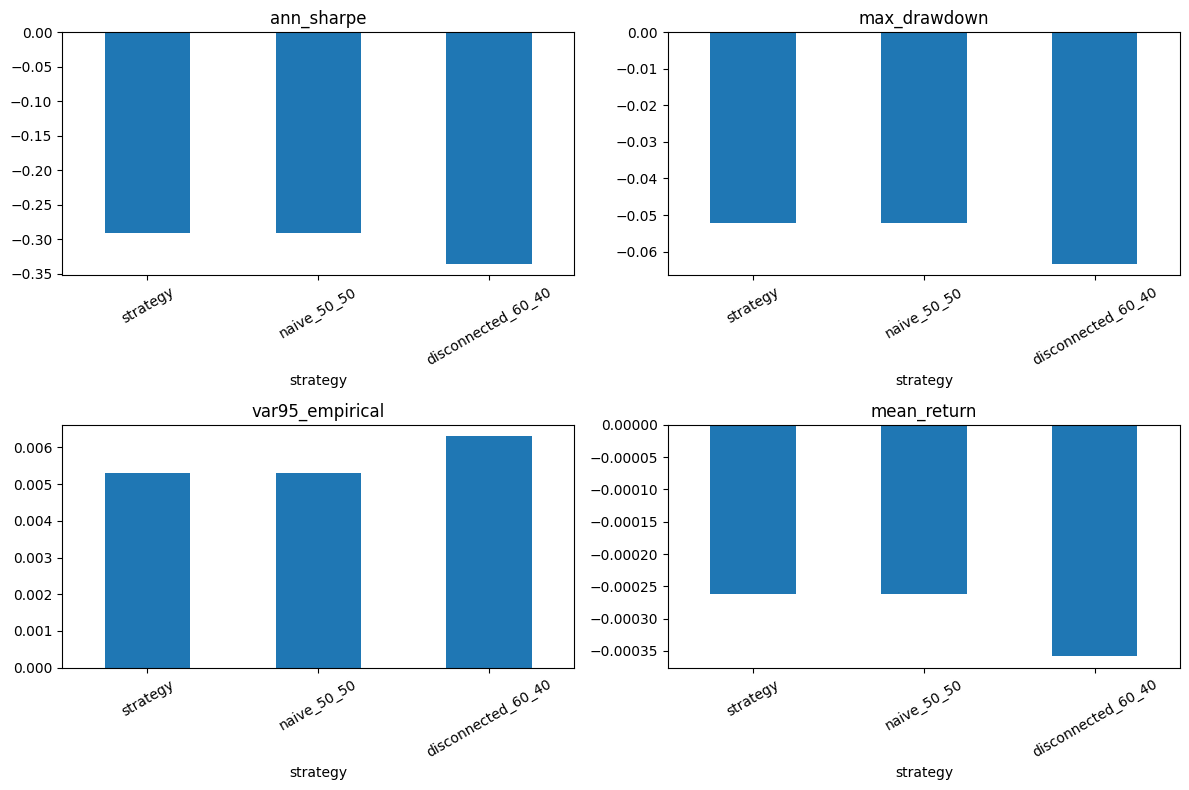

## ML Strategy Metrics

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return,hit_ratio,active_pct
0,ml_strategy,1.9348,-0.0024,0.0018,0.002083,0.5278,0.6389
1,ml_passive_spread,-0.8269,-0.0700,0.0112,-0.001422,0.3333,1.0000


In [6]:
# Compare strategy vs baselines on key metrics
metric_cols = ['ann_sharpe', 'max_drawdown', 'var95_empirical', 'mean_return']
show = pf[['strategy'] + metric_cols].copy() if not pf.empty else pd.DataFrame(columns=['strategy'] + metric_cols)
display(Markdown('## Strategy vs Baselines (Key Metrics)'))
display(show)

if not show.empty:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col in zip(axes.flatten(), metric_cols):
        show.plot(x='strategy', y=col, kind='bar', ax=ax, rot=30, legend=False, title=col)
    plt.tight_layout()
    plt.show()

ml_show = ml_pf[['strategy'] + [c for c in metric_cols + ['hit_ratio', 'active_pct'] if c in ml_pf.columns]].copy() if not ml_pf.empty else pd.DataFrame()
display(Markdown('## ML Strategy Metrics'))
display(ml_show)

## Interpretation prompts

- Does the strategy improve Sharpe vs naive and disconnected baselines?
- Are drawdown and empirical VaR acceptable for your target constraints?
- If differences are small, does signal confidence/weight mapping need recalibration?

In [ ]:
# Major results summary (portfolio + risk)
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = ROOT / 'data' / 'processed'

classical_path = PROCESSED / 'portfolio_backtest_summary.csv'
ml_path = PROCESSED / 'ml_backtest_summary.csv'

if not classical_path.exists():
    display(Markdown('**Major-results summary unavailable:** missing `portfolio_backtest_summary.csv`.'))
else:
    classical = pd.read_csv(classical_path)
    ml = pd.read_csv(ml_path) if ml_path.exists() else pd.DataFrame()

    # Keep major reported rows
    keep_classical = classical[classical['strategy'].isin(['strategy', 'naive_50_50', 'disconnected_60_40'])].copy()
    keep_classical['family'] = 'Classical allocation layer'

    major = [keep_classical]
    if not ml.empty:
        keep_ml = ml[ml['strategy'].isin(['ml_strategy', 'ml_passive_spread'])].copy()
        keep_ml['family'] = 'ML directional layer'
        major.append(keep_ml)

    major_df = pd.concat(major, ignore_index=True)
    metric_cols = [c for c in ['family', 'strategy', 'ann_sharpe', 'max_drawdown', 'var95_empirical', 'mean_return', 'hit_ratio', 'active_pct'] if c in major_df.columns]

    display(Markdown('## Major Results — Portfolio and Risk'))
    display(major_df[metric_cols].round(4))

    if 'strategy' in classical.columns:
        s = classical[classical['strategy'] == 'strategy']
        n = classical[classical['strategy'] == 'naive_50_50']
        if not s.empty and not n.empty:
            delta = pd.DataFrame([
                {
                    'Delta strategy_minus_naive': 'classical',
                    'ann_sharpe_delta': float(s['ann_sharpe'].iloc[0] - n['ann_sharpe'].iloc[0]),
                    'max_drawdown_delta': float(s['max_drawdown'].iloc[0] - n['max_drawdown'].iloc[0]),
                    'var95_empirical_delta': float(s['var95_empirical'].iloc[0] - n['var95_empirical'].iloc[0]),
                    'mean_return_delta': float(s['mean_return'].iloc[0] - n['mean_return'].iloc[0]),
                }
            ])
            display(Markdown('### Strategy uplift vs naive baseline'))
            display(delta.round(6))